# 🏏 IPL Streaks, Rebuilt: what a winning run is actually worth

**Version 2.** The first version of this analysis asked a good question — *can a team make the
playoffs without ever winning three in a row?* — and answered it with three numbers that
disagreed with each other. This notebook rebuilds it.

The honest summary of what changed:

| v1 claim | Status | v2 finding |
|---|---|---|
| A streak-capped team reaches 7+ wins **8.7%** of the time (math) | ❌ arithmetic error | **24.7%** — v1 divided by all 16,384 sequences instead of the 5,768 valid ones |
| …but **40.6%** of the time in simulation, so "math underestimates the difficulty" | ❌ different model | The simulation forced a free loss after every second win. Like-for-like, there is no gap to explain |
| Only ~40% of average teams manage a 3-match win streak | ❌ off by 25 points | **64.8%** at a 50% win rate. 40% is the *weak*-team number |
| 7 wins gives you a chance, 8 wins is basically safe | ⚠️ era-dependent | True in the 8-team era. Since 2022: 7 wins ≈ **15%**, 8 wins ≈ **74%**, and 9 wins is the real safety line |
| Teams with 3+ win streaks qualify; teams without them don't | ❌ confounded | The identical pattern appears in a simulated league built with **zero momentum**. Hold the win total fixed and the streak effect is flat |

Nothing here is a criticism of asking the question. The question is a good one. It just needs a
model that answers *it* rather than a neighbouring question, and a design that can tell a real
effect apart from an arithmetic inevitability.

---

### How to read this notebook

Every number is computed by the modules in `src/` and locked down by tests in `tests/`
(`python -m pytest -q`). Nothing is pasted in. If you change a model, the tests tell you which
sentence in this notebook you just invalidated.

In [1]:
import sys
from pathlib import Path

# On Kaggle or Colab:  !git clone https://github.com/piyushdash94/ipl-streak-analysis && %cd ipl-streak-analysis
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "streaks.py").exists())
sys.path.insert(0, str(ROOT))
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd

from src import analysis, cricsheet, league, momentum, streaks, viz

pd.set_option("display.width", 200)
pd.set_option("display.precision", 3)

---
## Part 1 — One question, three answers

The question: **a team never wins more than two matches in a row. How often does it still reach
7 wins in 14?**

There are two defensible ways to formalise "never wins more than two in a row", and they are not
the same thing:

1. **Conditional.** Play 14 independent matches, each won with probability $p$; then look only at
   the seasons where the longest run of wins happened to be ≤ 2. This is what "a team that never
   won three in a row" means as a description of a season you observed.
2. **Forced reset.** After two wins, the third match is a guaranteed loss. This is a rule imposed
   on the team, not a description of what happened.

v1 computed (1) by enumeration and (2) by simulation, then plotted them side by side as "math
model vs simulation model" — as if the gap between them said something about modelling. It didn't;
they are answers to different questions. And the enumeration had a separate bug on top.

In [2]:
table = analysis.model_comparison()
table.round(2)

,p_win,v1_math_7plus,v1_math_8plus,v1_sim_7plus,v1_sim_8plus,correct_conditional_7plus,correct_conditional_8plus,unconstrained_7plus
0,0.4,8.69,2.49,17.16,4.43,10.22,2.09,30.75
1,0.5,8.69,2.49,40.60,15.56,24.69,7.07,60.47
2,0.6,8.69,2.49,67.93,36.92,45.16,17.64,84.99


In [3]:
print(f"All W/L sequences of length 14        : {table.attrs['n_all_sequences']:,}")
print(f"…of which no more than 2 wins in a row: {table.attrs['n_valid_sequences']:,}")
print()
print("v1's 'math model' constant was 8.69%.  Reproducing it:")
print(f"  P(valid AND 7+ wins) at p=0.5 = {table.attrs['v1_denominator_check']:.2f}%   <- v1 used this")
print(f"  P(7+ wins | valid)   at p=0.5 = {table[table.p_win==0.5]['correct_conditional_7plus'].iloc[0]:.2f}%   <- the question actually asked")

All W/L sequences of length 14        : 16,384
…of which no more than 2 wins in a row: 5,768

v1's 'math model' constant was 8.69%.  Reproducing it:
  P(valid AND 7+ wins) at p=0.5 = 8.69%   <- v1 used this
  P(7+ wins | valid)   at p=0.5 = 24.69%   <- the question actually asked


So 8.69% is a **joint** probability — "how likely is a team to be *both* streak-capped *and* on 7+
wins" — presented as a **conditional** one. That single misplaced denominator makes the constraint
look about three times more punishing than it is.

This is the most common mistake in applied probability and it is worth internalising early: when you
filter a population and then divide by the size of the *unfiltered* population, you have answered a
different question. Always write the probability out in words before you divide.

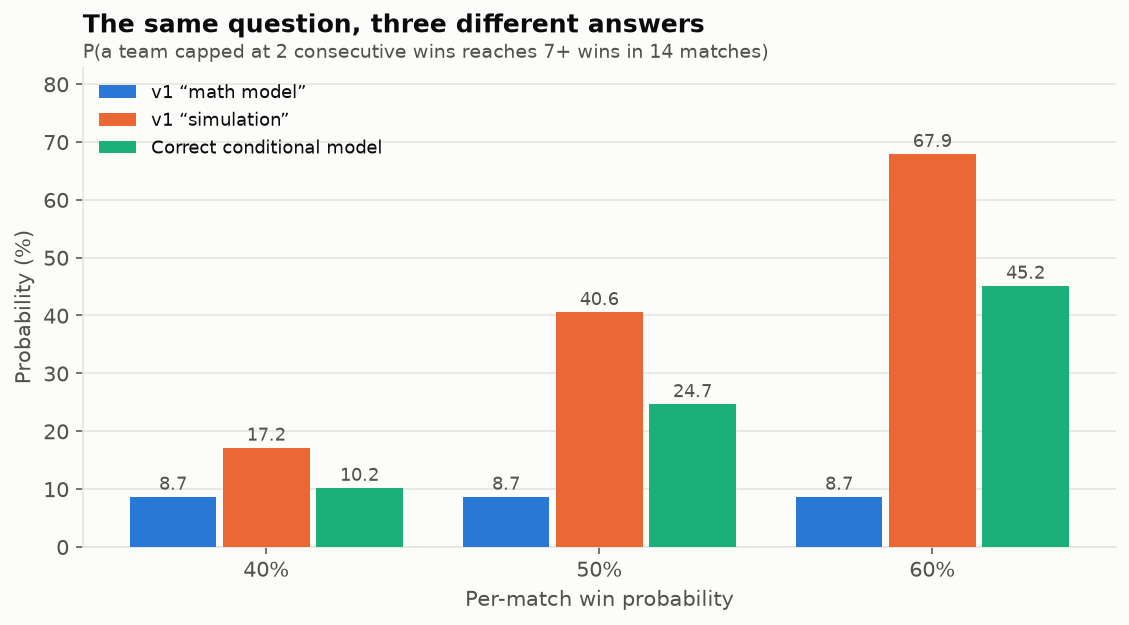

In [4]:
viz.plot_model_comparison(table, FIGURES / "model_comparison.png")
from IPython.display import Image; Image(FIGURES / "model_comparison.png")

The forced-reset model sits *above* the correct answer at every strength, not below it. So v1's
conclusion — "math models underestimate how difficult qualification is" — points the wrong way as
well as resting on a bug. The free loss after each pair of wins costs the team a match but no coin
flip, which quietly hands it a better season than the constraint really allows.

**Expected wins in 14 matches at $p = 0.5$:** unconstrained 7.00, forced-reset 6.10, conditional 5.51.

---
## Part 2 — Streaks are ordinary

Before asking whether streaks *predict* anything, it is worth knowing how often they simply happen.
These are exact probabilities for 14 independent matches — no momentum assumed, no simulation error.

In [5]:
freq = analysis.streak_frequency()
freq.pivot(index="streak_length", columns="p_win", values="probability").round(1)

p_win,0.4,0.5,0.6
streak_length,,,
1,99.9,100.0,100.0
2,83.0,94.0,98.5
3,42.7,64.8,83.1
4,17.3,34.9,56.8
5,6.5,16.8,34.2
6,2.4,7.8,19.4


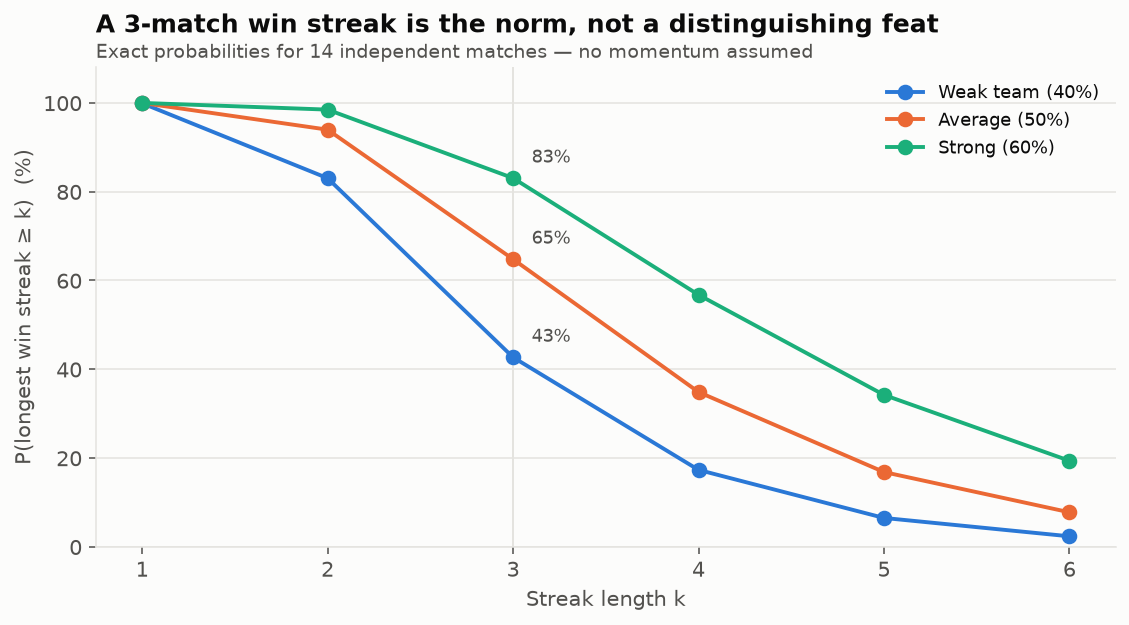

In [6]:
viz.plot_streak_frequency(freq, FIGURES / "streak_frequency.png")
Image(FIGURES / "streak_frequency.png")

A coin-flipping team produces a 3-match win streak in **65%** of seasons. A strong team does so in
**83%**. v1's app told readers "only ~40% of simulated teams achieve a 3+ win streak" — that is the
*weak*-team number (42.7%), applied to the average case.

This matters for the argument, not just the arithmetic. If two thirds of average teams produce a
3-match streak by chance alone, then "the champions had a 3-match streak" is close to saying "the
champions played 14 matches". A fact that is true of most teams cannot explain why four of them
qualified.

---
## Part 3 — What is a win total actually worth?

v1 assumed *7 wins gives you a chance, 8 wins is basically safe* and built everything on top of it.
That assumption is never checked anywhere in v1, and it can't be checked by a single-team model:
qualification is **relative**. You do not qualify by reaching 14 points; you qualify by finishing
above six other teams in a table that has to add up.

So here is a whole league. Ten teams, the real 2022+ fixture structure (70 matches, 14 each),
Bradley–Terry strengths, four playoff places, ranked on points then NRR. Wins are conserved — every
match has a winner and a loser — which is exactly what a single-team simulation cannot do.

In [7]:
curves, cutoffs = analysis.format_comparison(n_seasons=30_000)
pivot = curves.pivot(index="wins", columns="n_teams", values="qualify_rate").mul(100).round(1)
pivot.columns = ["8-team era (2014–2021)", "10-team era (2022– )"]
pivot.loc[5:11]

,8-team era (2014–2021),10-team era (2022– )
wins,,
5,0.1,0.0
6,5.5,0.2
7,49.7,14.9
8,94.5,74.3
9,99.9,98.7
10,100.0,100.0
11,100.0,100.0


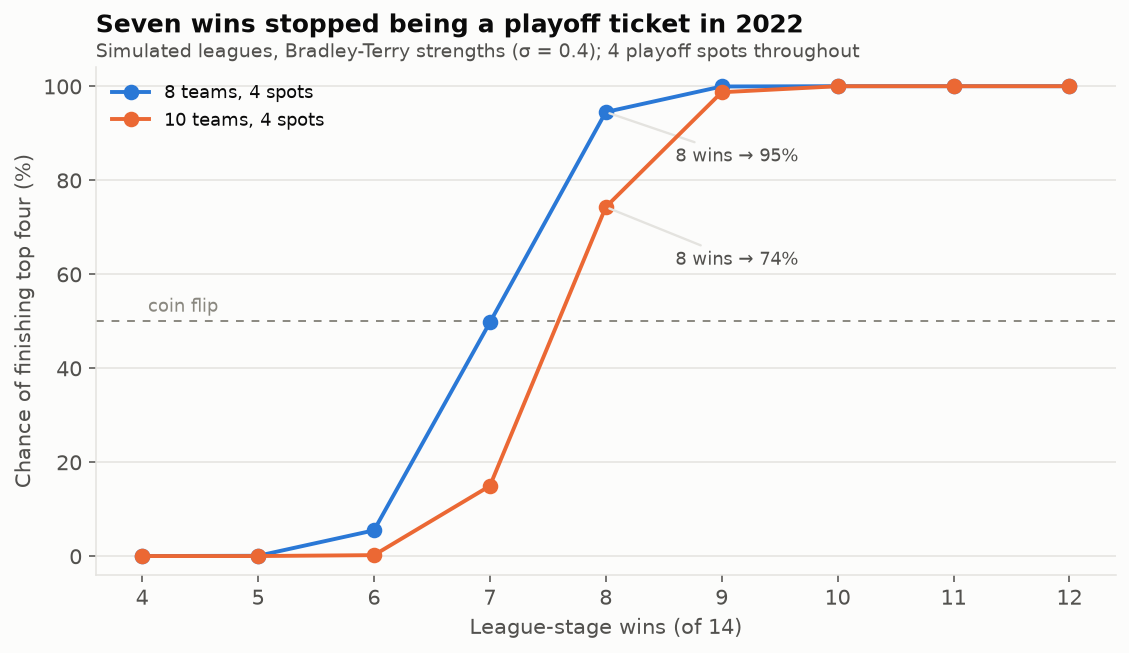

In [8]:
viz.plot_qualification_curve(curves, FIGURES / "qualification_curve.png")
Image(FIGURES / "qualification_curve.png")

In [9]:
cutoffs.pivot(index="cutoff_points", columns="n_teams", values="share").round(3)

n_teams,8,10
cutoff_points,,
10,0.000,NaN
12,0.066,0.003
14,0.519,0.225
16,0.379,0.618
18,0.036,0.149
20,0.000,0.005
22,NaN,0.000


**This is the finding with the most practical value in the notebook.**

When eight teams chased four places, *half the league qualified*. Seven wins was a genuine coin flip
(≈50%) and eight wins was close to safe (≈95%). v1's base assumption was a reasonable summary of
that era.

Ten teams chase the same four places. Seven wins is now worth about **15%** — it is not a playoff
position, it is a lottery ticket. Eight wins is **~74%**, which is a good position and emphatically
not "safe". The line that actually settles it is **nine wins / 18 points**.

The 4th-place cutoff most often lands on **16 points** in the 10-team format, which is precisely why
NRR keeps deciding IPL playoff races: the format manufactures ties at the cutoff. Sixteen points is
where the traffic jam is.

*Caveat, stated plainly:* Bradley–Terry dispersion (σ) cannot be fitted to real results in the
environment this notebook was built in — cricsheet.org is unreachable here. Every number above was
checked at σ ∈ {0.0, 0.4, 0.8} and the ordering never changes; the 10-team figure for 7 wins moves
only between 13% and 17%. Part 6 fits σ properly once you can reach the data.

---
## Part 4 — The streak effect that isn't

v1 ended on: *teams that build 3+ match win streaks qualify; teams that don't, mostly fail.* The
supporting evidence was a set of real campaigns picked to illustrate it.

Here is the problem. A team's longest win streak is not independent of how many matches it won — it
is **mechanically produced** by them. A 10-win team can hardly avoid a 3-match run; a 4-win team can
hardly produce one. So "streak teams qualify" and "teams that win a lot qualify" will look identical
in the data whether or not momentum exists at all.

There is a clean way to settle this: **run the comparison in a world where momentum provably does not
exist.** In the simulation below, each team's results are placed in a uniformly random order. There
is no momentum in the data-generating process — zero, by construction. If v1's pattern shows up here
anyway, then the pattern is not evidence of momentum.

In [10]:
confound = analysis.confound_analysis(n_seasons=40_000)
confound["marginal"].round(3)

,streak_threshold,share_of_teams,qualify_rate_with,qualify_rate_without
0,2,0.911,0.439,0.001
1,3,0.632,0.595,0.066
2,4,0.367,0.759,0.192
3,5,0.198,0.874,0.283


It reproduces, and it reproduces *strongly*. In a league with no momentum whatsoever, teams with a
3+ win streak qualify **59.5%** of the time against **6.6%** for teams without one — a nine-fold gap,
comfortably large enough to build a confident conclusion on. v1's headline finding is fully explained
without momentum existing.

Now the fix: compare teams that won the **same number of matches** and differ only in how those wins
were arranged.

In [11]:
strat = confound["stratified"]
strat[strat.wins.isin([7, 8, 9])].pivot(
    index="max_streak", columns="wins", values="qualified_rate"
).mul(100).round(1)

wins,7,8,9
max_streak,,,
2,15.5,74.2,98.9
3,14.8,74.6,98.8
4,14.7,74.2,98.7
5,15.7,74.2,98.8
6,13.5,73.7,98.5
7,NaN,75.2,98.6
8,NaN,NaN,98.0


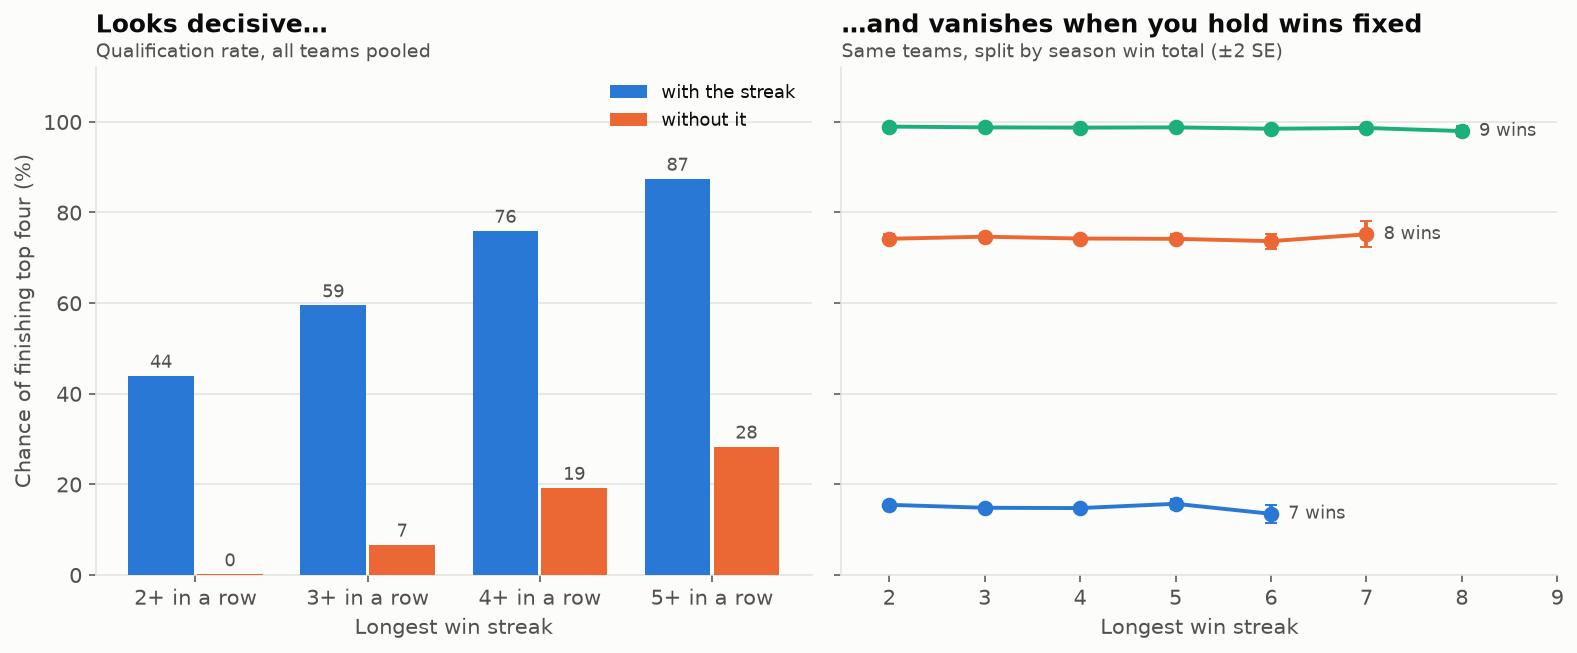

In [12]:
viz.plot_confound(confound["marginal"], strat, FIGURES / "confound.png")
Image(FIGURES / "confound.png")

In [13]:
confound["logit"].round(4)

,model,term,coef,std_err,z,p_value,odds_ratio,pseudo_r2
0,streak only,max_streak,1.229,0.004,302.576,0.000,3.419,0.339
1,wins only,wins,2.986,0.011,261.965,0.000,19.798,0.746
2,wins + streak,wins,2.991,0.012,249.006,0.000,19.909,0.746
3,wins + streak,max_streak,-0.010,0.007,-1.490,0.136,0.990,0.746


Read the regression from top to bottom:

- **Streak alone:** odds ratio 3.42, $z \approx 303$. Overwhelmingly "significant". Pseudo-$R^2$ 0.34.
- **Wins alone:** pseudo-$R^2$ 0.746. Wins do the work.
- **Wins + streak:** the streak coefficient is $-0.010$ ($p = 0.14$) and pseudo-$R^2$ does not move at
  all — 0.746 either way.

A predictor with $z = 303$ that contributes exactly nothing once you control for one obvious variable
is the textbook shape of a confound. And remember: this is simulated data with *no momentum in it*,
so "no effect" is the correct answer, and the method returns it.

The lesson generalises well beyond cricket. Two habits are worth taking from this:

1. **A huge $z$-statistic is not evidence of a mechanism.** With 400,000 rows, anything correlated
   with the outcome is significant. Effect size and incremental fit are what matter.
2. **Before believing a finding, ask what a null world would look like.** If you can simulate a world
   where your hypothesis is false and your finding still appears, the finding isn't evidence for the
   hypothesis. This costs twenty minutes and is the single highest-return habit in applied analysis.

---
## Part 5 — How you *would* test momentum properly

None of the above proves momentum doesn't exist in the IPL. It shows that v1's evidence doesn't
bear on the question. Testing it properly needs a design where win totals are held fixed and only
**order** varies.

That design is the **within-season permutation test**, the standard tool from the hot-hand
literature. Take each team-season's actual results and shuffle them. Every team keeps its exact
record — 7 wins stays 7 wins — but the ordering is destroyed. Repeat 5,000 times, and compare the
real streak statistic against that null distribution.

It assumes nothing about win probabilities, needs no model of team strength, and its null is exactly
the right one: *the same teams, the same records, chance ordering.*

In [14]:
rng = np.random.default_rng(2026)

def markov_season(n, p_after_win, p_after_loss, rng):
    """A season with genuine momentum: winning raises the next-match win chance."""
    seq, prev = [], rng.random() < 0.5
    for _ in range(n):
        prev = rng.random() < (p_after_win if prev else p_after_loss)
        seq.append(int(prev))
    return np.array(seq, dtype=np.int8)

no_momentum = [(rng.random(14) < 0.5).astype(np.int8) for _ in range(170)]
real_momentum = [markov_season(14, 0.62, 0.38, rng) for _ in range(170)]

print("League with NO momentum in it:")
print(" ", momentum.permutation_test(no_momentum, n_permutations=2000, seed=1))
print("\nLeague WITH momentum planted in it:")
print(" ", momentum.permutation_test(real_momentum, n_permutations=2000, seed=2))

League with NO momentum in it:


  observed=3.2235  null=3.1742 (sd 0.0785)  p(one-sided)=0.2729  p(two-sided)=0.5462

League WITH momentum planted in it:


  observed=3.8647  null=3.2811 (sd 0.0818)  p(one-sided)=0.0005  p(two-sided)=0.0005


The test stays quiet when there is nothing there and fires when there is. That is the minimum bar for
believing a result, and it is worth checking explicitly before pointing any test at real data.

The next question is one most analyses skip and shouldn't: **would this test even be able to detect
momentum in the IPL, given how little data there is?** IPL 2008–2025 is roughly 170 team-seasons of
14 matches. A test with no power is worse than no test, because "we found nothing" would then mean
nothing.

In [15]:
power = analysis.momentum_power_curve(n_team_seasons=170, trials=120)
power.round(3)

,momentum_gap,p_win_after_win,p_win_after_loss,power_at_5pct
0,0.00,0.500,0.500,0.042
1,0.05,0.525,0.475,0.350
2,0.10,0.550,0.450,0.792
3,0.15,0.575,0.425,0.983
4,0.20,0.600,0.400,1.000


With the full IPL history, the test has **79% power** against a 10-percentage-point momentum effect
(a team winning 55% after a win and 45% after a loss) and 98% power against a 15-point effect. Its
false-positive rate comes out at 4.2%, against a nominal 5%.

So the real-data test in Part 6 will be conclusive for effects of practical size — and if it comes
back null, that null is informative rather than merely underpowered. At a 5-point effect the test
fires only 35% of the time, so a null there would mean little; saying so up front is part of the
analysis, not a disclaimer bolted on afterwards.

---
## Part 6 — Running this on real IPL data (2008 →, including 2026)

Everything above is exact mathematics or simulation with a known generating process, which is what
makes the *methodological* conclusions solid. The remaining question — does the IPL actually show
momentum? — needs real match results.

`src/cricsheet.py` handles that. [Cricsheet](https://cricsheet.org) publishes every IPL match as
JSON under CC BY 4.0, which is the right source here: complete, versioned and machine-readable,
unlike the hand-typed W/L strings v1 relied on (several of which do not match the actual campaigns
they claim to represent).

Two design choices worth flagging:

- **Season is derived from match dates, not Cricsheet's `season` field.** That field is inconsistent
  ("2007/08", "2020/21", "2023"); every IPL season sits inside one calendar year, so the dates are
  the reliable key. This is also why **2026 needs no code change** — whatever seasons the archive
  holds when you run it, including 2026, are picked up automatically.
- **Qualification is read off the data, not inferred from points.** A team qualified in season *Y*
  if and only if it appears in a playoff match that season. That sidesteps reconstructing Net Run
  Rate from deliveries, which is genuinely fiddly once Duckworth–Lewis revisions and the
  all-out-counts-as-full-quota rule are involved, and which would only add error here.

A `validate()` report runs first, and you should read it before trusting anything downstream: it
checks that every team played the same number of league matches, that points sum to 2 per match, and
that exactly four teams reached the playoffs each season.

In [16]:
try:
    matches, team_seasons, report = cricsheet.load(ROOT / "data" / "ipl_json.zip" if (ROOT / "data" / "ipl_json.zip").exists() else None)   # downloads ~5 MB on first run
except RuntimeError as exc:
    print("Cricsheet is unreachable from this environment:\n ", exc)
    matches = team_seasons = report = None
else:
    display(report)
    if not report["all_ok"].all():
        print("Seasons flagged above need inspection before their numbers are used.")

Cricsheet is unreachable from this environment:
  could not download https://cricsheet.org/downloads/ipl_json.zip (<urlopen error Tunnel connection failed: 403 Forbidden>). Run this where cricsheet.org is reachable, or download the zip by hand and place it at data/ipl_json.zip.


In [17]:
if team_seasons is not None:
    real = analysis.real_data_analysis(team_seasons)

    print("Does IPL ordering produce longer streaks than chance, given the same records?")
    print(" ", real["permutation_max_streak"])
    print("\nDo wins follow wins more often than they follow losses?")
    print(f"  P(W|prev W) - P(W|prev L) = {real['serial_dependence']:+.4f}")
    print(" ", real["permutation_serial_dependence"])
    print("\nQualification by points, actual IPL:")
    display(real["qualification_by_points"])
    print("\nStreak effect, before and after controlling for wins:")
    display(real["logit"].round(4))
else:
    print("Skipped — run this cell where cricsheet.org is reachable.")

Skipped — run this cell where cricsheet.org is reachable.


**How to read the output when you run it.**

- If `permutation_max_streak` comes back with a high $p$-value, IPL win streaks are exactly as long
  as chance produces for teams with those records. Given the power curve in Part 5, that would be a
  real null result, not an absence of evidence — and the honest headline becomes *"IPL streaks are
  what randomness looks like."*
- If it comes back significant, momentum is worth taking seriously, and the next step is asking
  whether it is momentum or simply **schedule strength clustering** — a team that draws three weak
  opponents in a row will produce a streak with no psychology involved at all. Controlling for
  opponent strength match by match is the natural follow-up, and Cricsheet has what you need for it.

Either way, note what has changed: the conclusion is now driven by a test with known calibration and
known power, not by three campaigns chosen because they told a good story.

---
## What this leaves us with

1. **The streak-constraint arithmetic was wrong twice** — a joint probability used as a conditional
   one, and two different stochastic processes compared as if they were the same model. Corrected:
   a streak-capped coin-flip team reaches 7 wins **24.7%** of the time, not 8.7%.
2. **Streaks are ordinary.** Two thirds of average teams produce a 3-match win streak. A fact true
   of most teams cannot explain why four of them qualify.
3. **The format changed what a win total is worth.** Seven wins was a coin flip when eight teams
   chased four places. With ten teams it is worth about 15%. Nine wins is the modern safety line,
   and 16 points is where the cutoff traffic jam sits — which is why NRR keeps deciding it.
4. **The headline streak finding was a confound.** It reproduces perfectly in a simulated league
   containing no momentum at all, and vanishes the moment you hold the win total fixed.
5. **The right test exists and is powered.** A within-season permutation test on ~170 team-seasons
   detects a 10-point momentum effect 79% of the time, and a 15-point one 98% of the time. Part 6
   runs it wherever Cricsheet is reachable.

**The revised takeaway, for a commentary box:** *build wins, not streaks.* The streak is the
scoreboard's way of telling you a team has been winning; it is not a separate thing to chase. And in
the ten-team era, the number that actually matters is nine wins — seven is a lottery ticket and eight
is a nervous night watching other people's net run rate.

### If you want to take this further

- **Fit σ from real data** and replace the sensitivity range in Part 3 with a calibrated number.
- **Control for opponent strength** in the momentum test. It is the single most likely explanation
  for any streakiness that does turn up.
- **Model NRR from deliveries.** Fiddly, but it would let you simulate the actual tiebreak instead of
  a proxy, and NRR decides more IPL playoff races than anything except wins.
- **Extend to the WPL or the T20 Blast.** The confound argument is format-independent; the
  qualification curve is not, and comparing them would be genuinely novel work.